# 05 KPI Engineering and Innovation Gap Analysis

This notebook connects company financials, drug approvals, clinical trials, biotech funding, and disease burden through custom analytical KPIs.

The goal is to evaluate how pharmaceutical innovation activity aligns with commercial opportunity, clinical development success, investment activity, and real-world disease burden during the 2010–2025 main analysis period.

The analysis focuses on custom portfolio KPIs such as R&D intensity, approval productivity, trial success rate, innovation activity score, disease burden rank, innovation rank, and innovation gap score.

In [1]:
# Import core libraries
# Reference: 01_data_quality_check.ipynb - Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options
# Reference: 01_data_quality_check.ipynb - Step 1
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load all project datasets
# Reference: 01_data_quality_check.ipynb - Step 3
pharma_financials = pd.read_csv("pharma_companies_financials.csv")
drug_approvals = pd.read_csv("drug_approvals.csv")
clinical_trials = pd.read_csv("clinical_trials.csv")
biotech_funding = pd.read_csv("biotech_funding.csv")
disease_burden = pd.read_csv("disease_burden.csv")

# Convert date columns
# Reference: 01_data_quality_check.ipynb - Step 13
drug_approvals["approval_date"] = pd.to_datetime(drug_approvals["approval_date"])
clinical_trials["completion_date"] = pd.to_datetime(clinical_trials["completion_date"])
biotech_funding["date"] = pd.to_datetime(biotech_funding["date"])

# Create main analysis period datasets: 2010–2025
# Reference: 02_financial_performance_eda.ipynb - Main analysis period definition
pharma_financials_main = pharma_financials[
    (pharma_financials["year"] >= 2010) & (pharma_financials["year"] <= 2025)
]

drug_approvals_main = drug_approvals[
    (drug_approvals["year"] >= 2010) & (drug_approvals["year"] <= 2025)
]

clinical_trials_main = clinical_trials[
    (clinical_trials["year"] >= 2010) & (clinical_trials["year"] <= 2025)
]

biotech_funding_main = biotech_funding[
    (biotech_funding["year"] >= 2010) & (biotech_funding["year"] <= 2025)
]

disease_burden_main = disease_burden[
    (disease_burden["year"] >= 2010) & (disease_burden["year"] <= 2025)
]

## Step 2: Validate Main Analysis Datasets

This step checks the shape and year range of all filtered datasets used in the KPI engineering and innovation gap analysis.

In [2]:
dataset_check = pd.DataFrame({
    "dataset": [
        "pharma_financials_main",
        "drug_approvals_main",
        "clinical_trials_main",
        "biotech_funding_main",
        "disease_burden_main"
    ],
    "rows": [
        pharma_financials_main.shape[0],
        drug_approvals_main.shape[0],
        clinical_trials_main.shape[0],
        biotech_funding_main.shape[0],
        disease_burden_main.shape[0]
    ],
    "columns": [
        pharma_financials_main.shape[1],
        drug_approvals_main.shape[1],
        clinical_trials_main.shape[1],
        biotech_funding_main.shape[1],
        disease_burden_main.shape[1]
    ],
    "min_year": [
        pharma_financials_main["year"].min(),
        drug_approvals_main["year"].min(),
        clinical_trials_main["year"].min(),
        biotech_funding_main["year"].min(),
        disease_burden_main["year"].min()
    ],
    "max_year": [
        pharma_financials_main["year"].max(),
        drug_approvals_main["year"].max(),
        clinical_trials_main["year"].max(),
        biotech_funding_main["year"].max(),
        disease_burden_main["year"].max()
    ]
})

dataset_check

,dataset,rows,columns,min_year,max_year
0,pharma_financials_main,459,10,2010,2025
1,drug_approvals_main,715,12,2010,2025
2,clinical_trials_main,595,12,2010,2025
3,biotech_funding_main,1201,10,2010,2025
4,disease_burden_main,3110,5,2010,2025


## Step 3: Create Company-Level Financial KPIs

This step creates company-level financial KPIs for the 2010–2025 main analysis period.

Calculated KPIs:

- Total Revenue
- Total R&D Spending
- Average Operating Margin
- Average Pipeline Size
- R&D Intensity

In [3]:
company_financial_kpis = (
    pharma_financials_main
    .groupby(["company_name", "ticker", "segment"])
    .agg(
        total_revenue_usd_bn=("revenue_usd_bn", "sum"),
        total_rd_spend_usd_bn=("rd_spend_usd_bn", "sum"),
        avg_operating_margin_pct=("operating_margin_pct", "mean"),
        avg_pipeline_size=("pipeline_size_est", "mean")
    )
    .reset_index()
)

company_financial_kpis["rd_intensity_pct"] = (
    company_financial_kpis["total_rd_spend_usd_bn"] / 
    company_financial_kpis["total_revenue_usd_bn"]
) * 100

company_financial_kpis = company_financial_kpis.sort_values(
    "total_revenue_usd_bn",
    ascending=False
).reset_index(drop=True)

company_financial_kpis.head(10)

,company_name,ticker,segment,total_revenue_usd_bn,total_rd_spend_usd_bn,avg_operating_margin_pct,avg_pipeline_size,rd_intensity_pct
0,Johnson & Johnson,JNJ,diversified_pharma,1257.64,150.92,21.375000,79.437500,12.000254
1,Pfizer,PFE,big_pharma,959.64,172.71,27.462500,109.812500,17.997374
2,Roche,ROG,big_pharma,915.30,164.75,27.275000,108.562500,17.999563
3,Novartis,NVS,big_pharma,804.72,144.84,27.006250,104.562500,17.998807
4,Merck,MRK,big_pharma,781.19,140.60,28.106250,103.187500,17.998182
5,Bayer,BAYN,diversified_pharma,779.43,93.55,15.675000,68.875000,12.002361
6,Sanofi,SAN,big_pharma,596.13,107.29,28.187500,95.562500,17.997752
7,AstraZeneca,AZN,big_pharma,534.71,96.25,27.618750,91.562500,18.000411
8,Abbott Laboratories,ABT,diversified_pharma,519.25,62.32,21.675000,60.625000,12.001926
9,AbbVie,ABBV,big_pharma,514.18,92.55,28.815385,95.846154,17.999533


## Step 4: Create Company-Level Drug Approval KPIs

This step creates company-level drug approval KPIs for the 2010–2025 main analysis period.

Calculated KPIs:

- Total Drug Approvals
- Blockbuster Count
- Mega-Blockbuster Count
- Estimated Commercial Output
- Average Estimated Peak Sales

In [4]:
company_approval_kpis = (
    drug_approvals_main
    .groupby("sponsor_company")
    .agg(
        total_approvals=("approval_id", "count"),
        blockbuster_count=("is_blockbuster", "sum"),
        mega_blockbuster_count=("is_mega_blockbuster", "sum"),
        estimated_commercial_output_usd_bn=("peak_sales_usd_bn_est", "sum"),
        avg_peak_sales_usd_bn=("peak_sales_usd_bn_est", "mean")
    )
    .reset_index()
)

company_approval_kpis = company_approval_kpis.sort_values(
    "total_approvals",
    ascending=False
).reset_index(drop=True)

company_approval_kpis.head(10)

,sponsor_company,total_approvals,blockbuster_count,mega_blockbuster_count,estimated_commercial_output_usd_bn,avg_peak_sales_usd_bn
0,Amgen,30,7,2,29.66,0.988667
1,Novo Nordisk,30,4,3,48.96,1.632000
2,J&J,28,4,0,18.62,0.665000
3,Vertex,28,7,1,27.61,0.986071
4,Novartis,27,5,1,18.30,0.677778
5,Merck,26,9,2,55.47,2.133462
6,AstraZeneca,26,5,0,17.96,0.690769
7,Acadia,25,3,0,8.27,0.330800
8,BMS,25,6,1,30.55,1.222000
9,BioMarin,25,5,2,23.42,0.936800


## Step 5: Combine Company Financial and Approval KPIs

This step combines company-level financial KPIs with company-level drug approval KPIs.

The combined table will allow productivity metrics such as approvals per R&D spending and commercial output per R&D spending.

In [5]:
company_kpis = company_financial_kpis.merge(
    company_approval_kpis,
    left_on="company_name",
    right_on="sponsor_company",
    how="left"
)

# Fill missing approval values with 0 for companies without approval records in the dataset
approval_columns = [
    "total_approvals",
    "blockbuster_count",
    "mega_blockbuster_count",
    "estimated_commercial_output_usd_bn",
    "avg_peak_sales_usd_bn"
]

company_kpis[approval_columns] = company_kpis[approval_columns].fillna(0)

company_kpis.head(10)

,company_name,ticker,segment,total_revenue_usd_bn,total_rd_spend_usd_bn,avg_operating_margin_pct,avg_pipeline_size,rd_intensity_pct,sponsor_company,total_approvals,blockbuster_count,mega_blockbuster_count,estimated_commercial_output_usd_bn,avg_peak_sales_usd_bn
0,Johnson & Johnson,JNJ,diversified_pharma,1257.64,150.92,21.375000,79.437500,12.000254,NaN,0.0,0.0,0.0,0.00,0.000000
1,Pfizer,PFE,big_pharma,959.64,172.71,27.462500,109.812500,17.997374,Pfizer,20.0,4.0,1.0,27.67,1.383500
2,Roche,ROG,big_pharma,915.30,164.75,27.275000,108.562500,17.999563,Roche,23.0,7.0,3.0,39.92,1.735652
3,Novartis,NVS,big_pharma,804.72,144.84,27.006250,104.562500,17.998807,Novartis,27.0,5.0,1.0,18.30,0.677778
4,Merck,MRK,big_pharma,781.19,140.60,28.106250,103.187500,17.998182,Merck,26.0,9.0,2.0,55.47,2.133462
5,Bayer,BAYN,diversified_pharma,779.43,93.55,15.675000,68.875000,12.002361,Bayer,19.0,1.0,0.0,7.41,0.390000
6,Sanofi,SAN,big_pharma,596.13,107.29,28.187500,95.562500,17.997752,Sanofi,20.0,5.0,1.0,15.82,0.791000
7,AstraZeneca,AZN,big_pharma,534.71,96.25,27.618750,91.562500,18.000411,AstraZeneca,26.0,5.0,0.0,17.96,0.690769
8,Abbott Laboratories,ABT,diversified_pharma,519.25,62.32,21.675000,60.625000,12.001926,NaN,0.0,0.0,0.0,0.00,0.000000
9,AbbVie,ABBV,big_pharma,514.18,92.55,28.815385,95.846154,17.999533,AbbVie,22.0,4.0,2.0,22.16,1.007273


## Step 6: Standardize Company Names Before KPI Merge

This step standardizes company names between the financials and drug approvals datasets.

Some companies use abbreviated names in the approvals dataset, such as `J&J` and `BMS`, while the financials dataset uses full company names. Standardizing these names is necessary before calculating company-level productivity KPIs.

In [6]:
# Create a copy to avoid changing the original approvals dataset
drug_approvals_company_clean = drug_approvals_main.copy()

# Standardize sponsor company names to match pharma_financials company_name values
company_name_mapping = {
    "J&J": "Johnson & Johnson",
    "BMS": "Bristol-Myers Squibb"
}

drug_approvals_company_clean["sponsor_company_clean"] = (
    drug_approvals_company_clean["sponsor_company"]
    .replace(company_name_mapping)
)

# Recreate company-level approval KPIs using cleaned sponsor names
company_approval_kpis_clean = (
    drug_approvals_company_clean
    .groupby("sponsor_company_clean")
    .agg(
        total_approvals=("approval_id", "count"),
        blockbuster_count=("is_blockbuster", "sum"),
        mega_blockbuster_count=("is_mega_blockbuster", "sum"),
        estimated_commercial_output_usd_bn=("peak_sales_usd_bn_est", "sum"),
        avg_peak_sales_usd_bn=("peak_sales_usd_bn_est", "mean")
    )
    .reset_index()
)

company_approval_kpis_clean = company_approval_kpis_clean.sort_values(
    "total_approvals",
    ascending=False
).reset_index(drop=True)

company_approval_kpis_clean.head(10)

,sponsor_company_clean,total_approvals,blockbuster_count,mega_blockbuster_count,estimated_commercial_output_usd_bn,avg_peak_sales_usd_bn
0,Amgen,30,7,2,29.66,0.988667
1,Novo Nordisk,30,4,3,48.96,1.632000
2,Vertex,28,7,1,27.61,0.986071
3,Johnson & Johnson,28,4,0,18.62,0.665000
4,Novartis,27,5,1,18.30,0.677778
5,Merck,26,9,2,55.47,2.133462
6,AstraZeneca,26,5,0,17.96,0.690769
7,Acadia,25,3,0,8.27,0.330800
8,BioMarin,25,5,2,23.42,0.936800
9,Bristol-Myers Squibb,25,6,1,30.55,1.222000


## Step 7: Rebuild Combined Company KPI Table

This step merges company financial KPIs with cleaned company approval KPIs after standardizing sponsor company names.

The resulting table will be used to calculate company-level productivity metrics.

In [7]:
company_kpis = company_financial_kpis.merge(
    company_approval_kpis_clean,
    left_on="company_name",
    right_on="sponsor_company_clean",
    how="left"
)

approval_columns = [
    "total_approvals",
    "blockbuster_count",
    "mega_blockbuster_count",
    "estimated_commercial_output_usd_bn",
    "avg_peak_sales_usd_bn"
]

company_kpis[approval_columns] = company_kpis[approval_columns].fillna(0)

company_kpis = company_kpis.drop(columns=["sponsor_company_clean"])

company_kpis.head(10)

,company_name,ticker,segment,total_revenue_usd_bn,total_rd_spend_usd_bn,avg_operating_margin_pct,avg_pipeline_size,rd_intensity_pct,total_approvals,blockbuster_count,mega_blockbuster_count,estimated_commercial_output_usd_bn,avg_peak_sales_usd_bn
0,Johnson & Johnson,JNJ,diversified_pharma,1257.64,150.92,21.375000,79.437500,12.000254,28.0,4.0,0.0,18.62,0.665000
1,Pfizer,PFE,big_pharma,959.64,172.71,27.462500,109.812500,17.997374,20.0,4.0,1.0,27.67,1.383500
2,Roche,ROG,big_pharma,915.30,164.75,27.275000,108.562500,17.999563,23.0,7.0,3.0,39.92,1.735652
3,Novartis,NVS,big_pharma,804.72,144.84,27.006250,104.562500,17.998807,27.0,5.0,1.0,18.30,0.677778
4,Merck,MRK,big_pharma,781.19,140.60,28.106250,103.187500,17.998182,26.0,9.0,2.0,55.47,2.133462
5,Bayer,BAYN,diversified_pharma,779.43,93.55,15.675000,68.875000,12.002361,19.0,1.0,0.0,7.41,0.390000
6,Sanofi,SAN,big_pharma,596.13,107.29,28.187500,95.562500,17.997752,20.0,5.0,1.0,15.82,0.791000
7,AstraZeneca,AZN,big_pharma,534.71,96.25,27.618750,91.562500,18.000411,26.0,5.0,0.0,17.96,0.690769
8,Abbott Laboratories,ABT,diversified_pharma,519.25,62.32,21.675000,60.625000,12.001926,0.0,0.0,0.0,0.00,0.000000
9,AbbVie,ABBV,big_pharma,514.18,92.55,28.815385,95.846154,17.999533,22.0,4.0,2.0,22.16,1.007273


## Step 8: Calculate Company-Level Productivity KPIs

This step calculates company-level innovation productivity metrics.

Calculated KPIs:

- Approval Productivity = Total Approvals / Total R&D Spending
- Commercial Output per R&D = Estimated Commercial Output / Total R&D Spending
- Blockbuster Rate = Blockbuster Count / Total Approvals

These metrics are exploratory portfolio metrics and should be interpreted as directional indicators, not official financial or scientific measures.

In [8]:
company_kpis["approval_productivity_per_bn_rd"] = (
    company_kpis["total_approvals"] / company_kpis["total_rd_spend_usd_bn"]
)

company_kpis["commercial_output_per_bn_rd"] = (
    company_kpis["estimated_commercial_output_usd_bn"] / company_kpis["total_rd_spend_usd_bn"]
)

company_kpis["blockbuster_rate_pct"] = np.where(
    company_kpis["total_approvals"] > 0,
    (company_kpis["blockbuster_count"] / company_kpis["total_approvals"]) * 100,
    0
)

company_productivity_view = (
    company_kpis[
        [
            "company_name",
            "ticker",
            "segment",
            "total_rd_spend_usd_bn",
            "total_approvals",
            "estimated_commercial_output_usd_bn",
            "approval_productivity_per_bn_rd",
            "commercial_output_per_bn_rd",
            "blockbuster_rate_pct"
        ]
    ]
    .sort_values("commercial_output_per_bn_rd", ascending=False)
    .reset_index(drop=True)
)

company_productivity_view.head(15)

,company_name,ticker,segment,total_rd_spend_usd_bn,total_approvals,estimated_commercial_output_usd_bn,approval_productivity_per_bn_rd,commercial_output_per_bn_rd,blockbuster_rate_pct
0,Moderna,MRNA,biotech,13.63,1.0,18.50,0.073368,1.357300,100.000000
1,Regeneron,REGN,biotech,27.95,24.0,34.67,0.858676,1.240429,33.333333
2,Novo Nordisk,NVO,big_pharma,61.98,30.0,48.96,0.484027,0.789932,13.333333
3,Eli Lilly,LLY,big_pharma,79.36,5.0,43.50,0.063004,0.548135,100.000000
4,Merck,MRK,big_pharma,140.60,26.0,55.47,0.184922,0.394523,34.615385
5,GSK,GSK,big_pharma,83.60,23.0,31.38,0.275120,0.375359,26.086957
6,Bristol-Myers Squibb,BMY,big_pharma,87.62,25.0,30.55,0.285323,0.348665,24.000000
7,Takeda,4502,big_pharma,64.18,18.0,21.96,0.280461,0.342163,16.666667
8,Amgen,AMGN,biotech,94.94,30.0,29.66,0.315989,0.312408,23.333333
9,Roche,ROG,big_pharma,164.75,23.0,39.92,0.139605,0.242307,30.434783


### Company Productivity KPI Observation

Company-level productivity KPIs show that approval count alone is not enough to evaluate innovation performance.

Some companies have many approvals, while others generate higher estimated commercial output from fewer approvals. For example, Eli Lilly shows high estimated commercial output despite a lower approval count, while companies such as Novo Nordisk and Regeneron combine stronger approval activity with meaningful commercial output.

These exploratory KPIs suggest that innovation performance should be evaluated using both quantity-based metrics, such as approval count, and value-based metrics, such as estimated commercial output per R&D spending.

## Step 10: Create Therapy Area Innovation Activity KPIs

This step creates therapy area-level innovation KPIs by combining drug approvals and clinical trial activity.

Calculated KPIs:

- Approval Count
- Estimated Commercial Output
- Blockbuster Count
- Trial Count
- Trial Success Rate
- Average Estimated Stock Impact

These metrics will be used later to compare innovation activity with disease burden.

In [9]:
approval_kpis_by_therapy = (
    drug_approvals_main
    .groupby("therapy_area")
    .agg(
        approval_count=("approval_id", "count"),
        estimated_commercial_output_usd_bn=("peak_sales_usd_bn_est", "sum"),
        avg_peak_sales_usd_bn=("peak_sales_usd_bn_est", "mean"),
        blockbuster_count=("is_blockbuster", "sum"),
        mega_blockbuster_count=("is_mega_blockbuster", "sum")
    )
    .reset_index()
)

trial_kpis_by_therapy = (
    clinical_trials_main
    .groupby("therapy_area")
    .agg(
        trial_count=("trial_id", "count"),
        successful_trials=("is_success", "sum"),
        failed_trials=("is_failure", "sum"),
        trial_success_rate_pct=("is_success", "mean"),
        avg_stock_impact_pct=("estimated_stock_impact_pct", "mean")
    )
    .reset_index()
)

trial_kpis_by_therapy["trial_success_rate_pct"] = (
    trial_kpis_by_therapy["trial_success_rate_pct"] * 100
)

therapy_innovation_kpis = approval_kpis_by_therapy.merge(
    trial_kpis_by_therapy,
    on="therapy_area",
    how="outer"
).fillna(0)

therapy_innovation_kpis = therapy_innovation_kpis.sort_values(
    "estimated_commercial_output_usd_bn",
    ascending=False
).reset_index(drop=True)

therapy_innovation_kpis

,therapy_area,approval_count,estimated_commercial_output_usd_bn,avg_peak_sales_usd_bn,blockbuster_count,mega_blockbuster_count,trial_count,successful_trials,failed_trials,trial_success_rate_pct,avg_stock_impact_pct
0,oncology,272,227.09,0.834890,49,10,179.0,62.0,82.0,34.636872,-4.849721
1,infectious,57,149.48,2.622456,16,7,58.0,43.0,5.0,74.137931,5.034483
2,rare_disease,68,93.56,1.375882,19,5,45.0,24.0,17.0,53.333333,-0.513333
3,neurology,94,90.50,0.962766,22,4,62.0,17.0,38.0,27.419355,-7.303226
4,metabolic,38,90.15,2.372368,11,5,47.0,29.0,5.0,61.702128,3.210638
5,immunology,66,80.45,1.218939,13,5,74.0,39.0,20.0,52.702703,-0.279730
6,cardiovascular,49,58.48,1.193469,11,3,67.0,54.0,9.0,80.597015,3.177612
7,ophthalmology,11,15.85,1.440909,4,1,0.0,0.0,0.0,0.000000,0.000000
8,respiratory,20,15.62,0.781000,3,1,23.0,18.0,4.0,78.260870,5.421739
9,psychiatry,20,9.68,0.484000,2,0,17.0,7.0,10.0,41.176471,-3.717647


## Step 11: Map Disease Burden Categories to Therapy Areas

This step maps disease burden categories to comparable therapy areas used in the drug approvals and clinical trials datasets.

This mapping is necessary because disease names and therapy area labels are not identical across datasets.

In [10]:
disease_to_therapy_mapping = {
    "Cancer": "oncology",
    "Cardiovascular disease": "cardiovascular",
    "Stroke": "cardiovascular",
    "Neurological disorders": "neurology",
    "Alzheimer's & dementias": "neurology",
    "Mental disorders": "psychiatry",
    "Diabetes": "metabolic",
    "Chronic respiratory": "respiratory",
    "Lower respiratory infections": "infectious",
    "Tuberculosis": "infectious",
    "Malaria": "infectious",
    "HIV/AIDS": "infectious",
    "Diarrheal diseases": "gastrointestinal",
    "Liver disease": "gastrointestinal",
    "Kidney disease": "gastrointestinal",
    "Neonatal disorders": "rare_disease",
    "Maternal disorders": "rare_disease",
    "Self-harm": "psychiatry"
}

disease_burden_mapped = disease_burden_main.copy()

disease_burden_mapped["therapy_area"] = disease_burden_mapped["disease"].map(
    disease_to_therapy_mapping
)

disease_burden_mapped[["disease", "therapy_area"]].drop_duplicates().sort_values("therapy_area")

,disease,therapy_area
0,Cardiovascular disease,cardiovascular
3140,Stroke,cardiovascular
2970,Liver disease,gastrointestinal
1780,Diarrheal diseases,gastrointestinal
2800,Kidney disease,gastrointestinal
1020,HIV/AIDS,infectious
1190,Tuberculosis,infectious
1610,Lower respiratory infections,infectious
1360,Malaria,infectious
340,Diabetes,metabolic


## Step 12: Finalize Therapy Area Mapping

This step updates the disease-to-therapy-area mapping by assigning COVID-19 to infectious disease and leaving road injuries unmapped.

Road injuries are excluded from therapy-area innovation gap comparison because they do not directly correspond to a pharmaceutical therapy area in this dataset.

In [11]:
# Update mapping for COVID-19
disease_to_therapy_mapping["COVID-19"] = "infectious"

# Reapply mapping
disease_burden_mapped = disease_burden_main.copy()

disease_burden_mapped["therapy_area"] = disease_burden_mapped["disease"].map(
    disease_to_therapy_mapping
)

# Check unmapped disease categories
unmapped_diseases = (
    disease_burden_mapped[disease_burden_mapped["therapy_area"].isna()]
    ["disease"]
    .drop_duplicates()
    .sort_values()
)

unmapped_diseases

2290    Road injuries
Name: disease, dtype: object

## Step 13: Create Therapy Area Disease Burden KPIs

This step aggregates disease burden data into therapy-area-level KPIs using the analytical mapping created above.

Road injuries are excluded because they do not map directly to a pharmaceutical therapy area in this dataset.

In [12]:
therapy_burden_kpis = (
    disease_burden_mapped
    .dropna(subset=["therapy_area"])
    .groupby("therapy_area")
    .agg(
        mapped_disease_count=("disease", "nunique"),
        avg_dalys_millions=("dalys_millions", "mean"),
        total_dalys_millions=("dalys_millions", "sum"),
        avg_global_dalys_millions=("global_dalys_millions", "mean")
    )
    .sort_values("avg_global_dalys_millions", ascending=False)
    .reset_index()
)

therapy_burden_kpis

,therapy_area,mapped_disease_count,avg_dalys_millions,total_dalys_millions,avg_global_dalys_millions
0,cardiovascular,2,26.353281,8433.05,263.796875
1,oncology,1,24.653313,3944.53,246.906250
2,neurology,2,14.134656,4523.09,141.093750
3,respiratory,1,10.243750,1639.00,102.187500
4,psychiatry,2,10.212719,3268.07,101.281250
5,rare_disease,2,9.488844,3036.43,92.062500
6,metabolic,1,7.562500,1210.00,75.375000
7,infectious,5,6.687225,4747.93,60.809859
8,gastrointestinal,3,5.051583,2424.76,50.437500


## Step 14: Combine Innovation Activity and Disease Burden KPIs

This step combines therapy-area innovation KPIs with therapy-area disease burden KPIs.

The combined table allows direct comparison between pharmaceutical innovation activity and real-world disease burden.

In [13]:
therapy_gap_base = therapy_innovation_kpis.merge(
    therapy_burden_kpis,
    on="therapy_area",
    how="inner"
)

therapy_gap_base = therapy_gap_base.sort_values(
    "avg_global_dalys_millions",
    ascending=False
).reset_index(drop=True)

therapy_gap_base

,therapy_area,approval_count,estimated_commercial_output_usd_bn,avg_peak_sales_usd_bn,blockbuster_count,mega_blockbuster_count,trial_count,successful_trials,failed_trials,trial_success_rate_pct,avg_stock_impact_pct,mapped_disease_count,avg_dalys_millions,total_dalys_millions,avg_global_dalys_millions
0,cardiovascular,49,58.48,1.193469,11,3,67.0,54.0,9.0,80.597015,3.177612,2,26.353281,8433.05,263.796875
1,oncology,272,227.09,0.834890,49,10,179.0,62.0,82.0,34.636872,-4.849721,1,24.653313,3944.53,246.906250
2,neurology,94,90.50,0.962766,22,4,62.0,17.0,38.0,27.419355,-7.303226,2,14.134656,4523.09,141.093750
3,respiratory,20,15.62,0.781000,3,1,23.0,18.0,4.0,78.260870,5.421739,1,10.243750,1639.00,102.187500
4,psychiatry,20,9.68,0.484000,2,0,17.0,7.0,10.0,41.176471,-3.717647,2,10.212719,3268.07,101.281250
5,rare_disease,68,93.56,1.375882,19,5,45.0,24.0,17.0,53.333333,-0.513333,2,9.488844,3036.43,92.062500
6,metabolic,38,90.15,2.372368,11,5,47.0,29.0,5.0,61.702128,3.210638,1,7.562500,1210.00,75.375000
7,infectious,57,149.48,2.622456,16,7,58.0,43.0,5.0,74.137931,5.034483,5,6.687225,4747.93,60.809859
8,gastrointestinal,9,3.93,0.436667,1,0,23.0,15.0,5.0,65.217391,2.704348,3,5.051583,2424.76,50.437500


## Step 15: Calculate Innovation Rank and Disease Burden Rank

This step ranks therapy areas by disease burden and innovation activity.

Ranking logic:

- Disease Burden Rank is based on average global DALYs.
- Approval Rank is based on approval count.
- Commercial Output Rank is based on estimated commercial output.
- Trial Activity Rank is based on trial count.

Lower rank values indicate stronger position, where rank 1 means highest burden or highest innovation activity.

In [14]:
therapy_gap_ranked = therapy_gap_base.copy()

therapy_gap_ranked["disease_burden_rank"] = therapy_gap_ranked[
    "avg_global_dalys_millions"
].rank(ascending=False, method="dense")

therapy_gap_ranked["approval_rank"] = therapy_gap_ranked[
    "approval_count"
].rank(ascending=False, method="dense")

therapy_gap_ranked["commercial_output_rank"] = therapy_gap_ranked[
    "estimated_commercial_output_usd_bn"
].rank(ascending=False, method="dense")

therapy_gap_ranked["trial_activity_rank"] = therapy_gap_ranked[
    "trial_count"
].rank(ascending=False, method="dense")

therapy_gap_ranked[
    [
        "therapy_area",
        "avg_global_dalys_millions",
        "disease_burden_rank",
        "approval_count",
        "approval_rank",
        "estimated_commercial_output_usd_bn",
        "commercial_output_rank",
        "trial_count",
        "trial_activity_rank"
    ]
].sort_values("disease_burden_rank")

,therapy_area,avg_global_dalys_millions,disease_burden_rank,approval_count,approval_rank,estimated_commercial_output_usd_bn,commercial_output_rank,trial_count,trial_activity_rank
0,cardiovascular,263.796875,1.0,49,5.0,58.48,6.0,67.0,2.0
1,oncology,246.906250,2.0,272,1.0,227.09,1.0,179.0,1.0
2,neurology,141.093750,3.0,94,2.0,90.50,4.0,62.0,3.0
3,respiratory,102.187500,4.0,20,7.0,15.62,7.0,23.0,7.0
4,psychiatry,101.281250,5.0,20,7.0,9.68,8.0,17.0,8.0
5,rare_disease,92.062500,6.0,68,3.0,93.56,3.0,45.0,6.0
6,metabolic,75.375000,7.0,38,6.0,90.15,5.0,47.0,5.0
7,infectious,60.809859,8.0,57,4.0,149.48,2.0,58.0,4.0
8,gastrointestinal,50.437500,9.0,9,8.0,3.93,9.0,23.0,7.0


## Step 16: Calculate Innovation Gap Score

This step calculates an exploratory Innovation Gap Score by comparing disease burden rank with innovation activity rank.

For this analysis:

- Innovation Rank is calculated as the average of approval rank, commercial output rank, and trial activity rank.
- Innovation Gap Score = Innovation Rank - Disease Burden Rank

Interpretation:

- Positive score: disease burden rank is stronger than innovation rank, suggesting possible under-prioritization.
- Negative score: innovation activity rank is stronger than disease burden rank, suggesting possible over-concentration or commercial/investment priority.
- Scores near zero suggest closer alignment between burden and innovation activity.

This is a custom exploratory metric created for portfolio analysis, not an official scientific or financial measure.

In [15]:
therapy_gap_ranked["innovation_rank"] = (
    therapy_gap_ranked[
        [
            "approval_rank",
            "commercial_output_rank",
            "trial_activity_rank"
        ]
    ].mean(axis=1)
)

therapy_gap_ranked["innovation_gap_score"] = (
    therapy_gap_ranked["innovation_rank"] - 
    therapy_gap_ranked["disease_burden_rank"]
)

innovation_gap_view = (
    therapy_gap_ranked[
        [
            "therapy_area",
            "avg_global_dalys_millions",
            "disease_burden_rank",
            "approval_count",
            "estimated_commercial_output_usd_bn",
            "trial_count",
            "innovation_rank",
            "innovation_gap_score"
        ]
    ]
    .sort_values("innovation_gap_score", ascending=False)
    .reset_index(drop=True)
)

innovation_gap_view

,therapy_area,avg_global_dalys_millions,disease_burden_rank,approval_count,estimated_commercial_output_usd_bn,trial_count,innovation_rank,innovation_gap_score
0,cardiovascular,263.796875,1.0,49,58.48,67.0,4.333333,3.333333
1,respiratory,102.187500,4.0,20,15.62,23.0,7.000000,3.000000
2,psychiatry,101.281250,5.0,20,9.68,17.0,7.666667,2.666667
3,neurology,141.093750,3.0,94,90.50,62.0,3.000000,0.000000
4,oncology,246.906250,2.0,272,227.09,179.0,1.000000,-1.000000
5,gastrointestinal,50.437500,9.0,9,3.93,23.0,8.000000,-1.000000
6,metabolic,75.375000,7.0,38,90.15,47.0,5.333333,-1.666667
7,rare_disease,92.062500,6.0,68,93.56,45.0,4.000000,-2.000000
8,infectious,60.809859,8.0,57,149.48,58.0,3.333333,-4.666667


## Step 17: Visualize Innovation Gap Score by Therapy Area

This step visualizes the Innovation Gap Score by therapy area.

Positive values suggest possible under-prioritization relative to disease burden, while negative values suggest higher innovation concentration relative to disease burden rank.

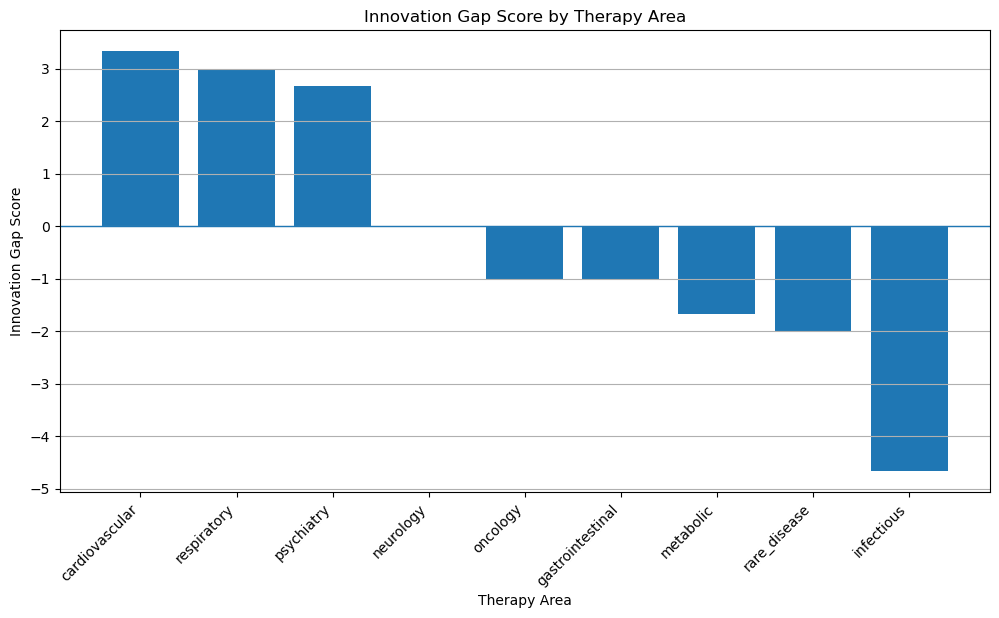

In [16]:
plt.figure(figsize=(12, 6))

plt.bar(
    innovation_gap_view["therapy_area"],
    innovation_gap_view["innovation_gap_score"]
)

plt.axhline(0, linewidth=1)

plt.title("Innovation Gap Score by Therapy Area")
plt.xlabel("Therapy Area")
plt.ylabel("Innovation Gap Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Innovation Gap Score Observation

The Innovation Gap Score suggests that pharmaceutical innovation activity does not align evenly with disease burden across therapy areas.

Cardiovascular, respiratory, and psychiatry show positive gap scores, suggesting that these areas may be relatively under-prioritized compared with their disease burden rank.

In contrast, infectious disease, rare disease, metabolic disease, and oncology show negative gap scores, suggesting stronger innovation activity relative to their disease burden rank.

Oncology remains a high-burden area, but it also receives very strong approval, trial, and commercial activity. Cardiovascular disease has the highest burden rank but weaker innovation rank, making it a potential under-prioritization signal for later discussion.

## Step 19: Estimate Funding Themes from Deal Descriptions

This step creates a simple keyword-based therapy area classification from biotech funding deal descriptions.

This is an exploratory text-matching approach. It is not a perfect classification model, but it helps estimate how funding activity may connect to major therapy areas.

In [17]:
def classify_funding_theme(description):
    text = str(description).lower()
    
    if any(keyword in text for keyword in ["oncology", "cancer", "tumor"]):
        return "oncology"
    elif any(keyword in text for keyword in ["infectious", "vaccine", "covid", "antiviral", "hiv"]):
        return "infectious"
    elif any(keyword in text for keyword in ["diabetes", "obesity", "glp-1", "metabolic"]):
        return "metabolic"
    elif any(keyword in text for keyword in ["neurology", "neuro", "alzheimer", "parkinson"]):
        return "neurology"
    elif any(keyword in text for keyword in ["cardiovascular", "heart", "cardio"]):
        return "cardiovascular"
    elif any(keyword in text for keyword in ["immunology", "immune", "autoimmune"]):
        return "immunology"
    elif any(keyword in text for keyword in ["rare disease", "rare", "orphan"]):
        return "rare_disease"
    elif any(keyword in text for keyword in ["respiratory", "lung", "asthma", "copd"]):
        return "respiratory"
    elif any(keyword in text for keyword in ["psychiatry", "mental", "depression"]):
        return "psychiatry"
    elif any(keyword in text for keyword in ["gastro", "liver", "kidney"]):
        return "gastrointestinal"
    else:
        return "other"

biotech_funding_themes = biotech_funding_main.copy()

biotech_funding_themes["therapy_area"] = biotech_funding_themes["description"].apply(
    classify_funding_theme
)

funding_theme_counts = (
    biotech_funding_themes
    .groupby("therapy_area")
    .agg(
        deal_count=("deal_id", "count"),
        total_funding_usd_bn=("value_usd_bn", "sum"),
        avg_deal_value_usd_bn=("value_usd_bn", "mean"),
        megadeal_count=("is_megadeal", "sum")
    )
    .sort_values("total_funding_usd_bn", ascending=False)
    .reset_index()
)

funding_theme_counts

,therapy_area,deal_count,total_funding_usd_bn,avg_deal_value_usd_bn,megadeal_count
0,other,1194,1793.583,1.502163,44
1,rare_disease,2,71.000,35.500000,2
2,immunology,2,15.700,7.850000,1
3,oncology,2,0.510,0.255000,0
4,cardiovascular,1,0.270,0.270000,0


### Funding Theme Classification Limitation

The keyword-based therapy area classification did not produce reliable funding categories.

Most biotech funding records were classified as `other`, which means the deal descriptions do not contain enough consistent therapy-area keywords for robust classification using this simple approach.

Because of this limitation, funding data will not be directly included in the therapy-area Innovation Gap Score in this notebook. Instead, biotech funding will be discussed separately as an investment concentration signal, especially around deal type, M&A activity, and megadeal concentration.

A more reliable funding-to-therapy-area analysis would require cleaner labeled funding data or more detailed deal descriptions.

## Step 21: Create Final Innovation Gap Summary Table

This step creates a final summary table for the Innovation Gap analysis.

The table includes disease burden rank, innovation rank, innovation gap score, approval count, estimated commercial output, trial count, and trial success rate by therapy area.

In [18]:
final_innovation_gap_summary = (
    therapy_gap_ranked[
        [
            "therapy_area",
            "avg_global_dalys_millions",
            "disease_burden_rank",
            "approval_count",
            "estimated_commercial_output_usd_bn",
            "trial_count",
            "trial_success_rate_pct",
            "innovation_rank",
            "innovation_gap_score"
        ]
    ]
    .sort_values("innovation_gap_score", ascending=False)
    .reset_index(drop=True)
)

final_innovation_gap_summary

,therapy_area,avg_global_dalys_millions,disease_burden_rank,approval_count,estimated_commercial_output_usd_bn,trial_count,trial_success_rate_pct,innovation_rank,innovation_gap_score
0,cardiovascular,263.796875,1.0,49,58.48,67.0,80.597015,4.333333,3.333333
1,respiratory,102.187500,4.0,20,15.62,23.0,78.260870,7.000000,3.000000
2,psychiatry,101.281250,5.0,20,9.68,17.0,41.176471,7.666667,2.666667
3,neurology,141.093750,3.0,94,90.50,62.0,27.419355,3.000000,0.000000
4,oncology,246.906250,2.0,272,227.09,179.0,34.636872,1.000000,-1.000000
5,gastrointestinal,50.437500,9.0,9,3.93,23.0,65.217391,8.000000,-1.000000
6,metabolic,75.375000,7.0,38,90.15,47.0,61.702128,5.333333,-1.666667
7,rare_disease,92.062500,6.0,68,93.56,45.0,53.333333,4.000000,-2.000000
8,infectious,60.809859,8.0,57,149.48,58.0,74.137931,3.333333,-4.666667


## Step 22: Final Innovation Gap Interpretation

The final Innovation Gap table suggests that pharmaceutical innovation activity does not align evenly with disease burden across therapy areas.

Cardiovascular disease shows the strongest possible under-prioritization signal. It has the highest disease burden rank, but weaker innovation activity rank based on approvals, estimated commercial output, and trial activity.

Respiratory and psychiatry also show positive gap scores, suggesting that these areas may receive less innovation activity relative to their disease burden.

Oncology shows the opposite pattern. It has a high disease burden rank, but even stronger innovation activity, ranking first in approvals, commercial output, and trial activity. This suggests that oncology is both a high-burden and highly concentrated innovation area.

Infectious disease, rare disease, metabolic disease, and oncology show negative gap scores, suggesting stronger innovation concentration relative to disease burden rank.

These findings should be interpreted as exploratory and directional. The Innovation Gap Score is a custom portfolio metric designed to compare relative rankings across datasets, not an official scientific measure.

# Notebook Summary and Next Steps

This notebook connected company financials, drug approvals, clinical trials, biotech funding, and disease burden through custom exploratory KPIs.

Completed analysis:

- Company-level financial KPIs
- Company-level drug approval KPIs
- Company-level productivity KPIs
- Therapy area innovation activity KPIs
- Disease burden to therapy area mapping
- Therapy area disease burden KPIs
- Innovation rank and disease burden rank comparison
- Innovation Gap Score calculation
- Funding theme classification limitation review

Key findings:

- Approval count alone is not enough to evaluate innovation performance.
- Estimated commercial output and R&D productivity provide additional insight into company-level innovation value.
- Oncology had the strongest innovation activity across approvals, commercial output, and trial activity.
- Cardiovascular disease had the highest disease burden but weaker innovation activity rank.
- Respiratory and psychiatry also showed possible under-prioritization signals.
- Infectious disease, rare disease, metabolic disease, and oncology showed stronger innovation concentration relative to disease burden rank.
- Funding data could not be reliably mapped to therapy areas using simple keyword classification because most records were classified as `other`.

Main project insight:

Pharmaceutical innovation activity appears unevenly aligned with global disease burden. Some high-burden areas, especially cardiovascular, respiratory, and psychiatry, may be relatively under-prioritized compared with their burden rank. Meanwhile, oncology shows strong alignment between high burden and high innovation concentration, and infectious disease shows high innovation concentration relative to burden rank.

Next steps:

The next stage of the project should prepare clean output tables for dashboarding and case study writing. Recommended outputs include:

- Final company KPI table
- Final therapy area innovation KPI table
- Final innovation gap summary table
- Dashboard-ready CSV exports
- Executive case study summary